# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**请填写**  
第5天专题（A/B/C/D/E）：**请填写**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [35]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "姚佳凤"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 姚佳凤
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [37]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均返现,平均距上次下单天数
0,0-12月,3552,846,0.24,2.56,159.99,3.98
1,13-24月,1574,102,0.06,3.64,200.72,5.24
2,25-36月,500,0,0.00,3.70,225.29,5.38
3,49-60月,2,0,0.00,2.50,161.50,8.50
4,60月以上,2,0,0.00,1.50,291.25,0.50


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,投诉状态,样本提示
0,0-12月,0,2533,394,0.16,2.53,无投诉,可观察
1,0-12月,1,1019,452,0.44,2.62,有投诉,可观察
2,13-24月,0,1135,46,0.04,3.79,无投诉,可观察
3,13-24月,1,439,56,0.13,3.27,有投诉,可观察
4,25-36月,0,356,0,0.00,3.82,无投诉,可观察


检查点1A通过：输入文件有效


In [38]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同偏好订单品类的平均现金返还金额是否存在差异？",
    "behavior_scatter": "用户生命周期与现金返还金额呈现什么关系？",
    "ordered_line": "用户平均订单数量如何随用户生命周期阶段性变化？",
    "composition_chart": "全部用户由哪些偏好订单品类类别构成？",
}

chart_reasons = {
    "category_bar": "柱状图适用于类别间指标对比，清晰展示不同偏好品类用户现金返还水平差异。",
    "behavior_scatter": "散点图用于探究两个连续数值变量之间的关联模式，观察用户生命周期和返现的相关特征",
    "ordered_line": "折线图适合有序分组数据，清晰展现指标跟随用户生命周期阶段的变动趋势。",
    "composition_chart": "构成图表（饼图/环形图）适合展示各类人群在整体用户中的占比结构。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [39]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "PreferedOrderCat"
category_summary = (
    df.groupby(category_field,observed = True)
    .agg(
        用户数=("CustomerID","nunique"),
        平均现金返还金额=("CashbackAmount","mean")
    )
    .reset_index()
)

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,PreferedOrderCat,用户数,平均现金返还金额
0,Fashion,826,210.41
1,Grocery,410,266.23
2,Laptop & Accessory,2050,167.22
3,Mobile Phone,2080,140.20
4,Others,264,304.56


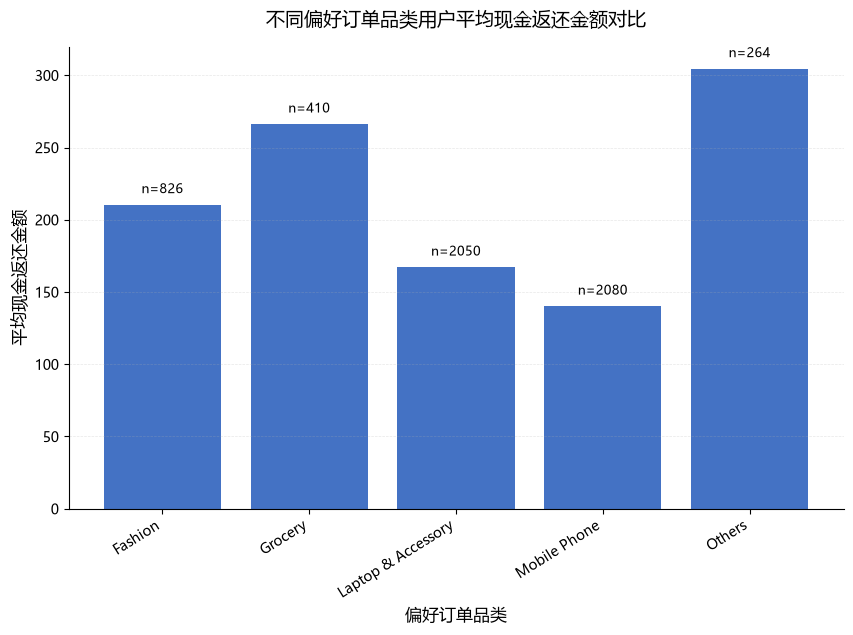

已输出： output\day06_visualization\01_category_bar.png


In [40]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
bars = ax_bar.bar(
    category_summary["PreferedOrderCat"],
    category_summary["平均现金返还金额"],
    color = '#4472C4'

)
#图标标题与坐标轴
ax_bar.set_title("不同偏好订单品类用户平均现金返还金额对比",fontsize =14,pad = 15)
ax_bar.set_xlabel("偏好订单品类",fontsize = 12)
ax_bar.set_ylabel("平均现金返还金额",fontsize = 12)
# x轴标签旋转避免重叠
plt.setp(ax_bar.get_xticklabels(), rotation=32, ha="right")

for bar, count in zip(bars, category_summary["用户数"]):
    h = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        h + 8,
        f"n={count}",
        ha="center", fontsize=9
    )

# 美化：去掉上、右边框，横向网格
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)
ax_bar.grid(axis="y", alpha=0.3, linestyle="--")

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()


assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：各偏好订单品类用户的平均现金返还金额存在显著高低区分，Others 类用户平均返现最高，手机品类用户平均返现最低
- 证据：Others (n=264) 人均返现＞300；Grocery (n=410) 约 267；Fashion (n=826) 约 210；Laptop & Accessory (n=2050) 约 168；Mobile Phone (n=2080) 约 142；小众品类返现均值更高，但样本数量远小于手机、电脑配件大类。
- 边界：无法证明品类偏好与现金返还存在因果关系。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


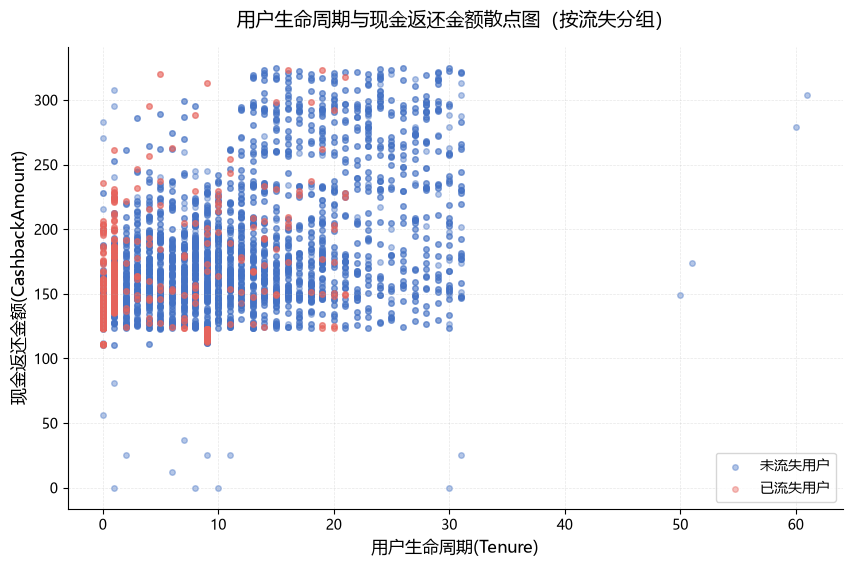

已输出： output\day06_visualization\02_behavior_scatter.png


In [41]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "Tenure"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
df_churn0 = df[df["Churn"] == 0]
df_churn1 = df[df["Churn"] == 1]

ax_scatter.scatter(df_churn0[x_field], df_churn0[y_field],
                   c="#4472C4", alpha=0.4, s=16, label="未流失用户")
ax_scatter.scatter(df_churn1[x_field], df_churn1[y_field],
                   c="#E7635C", alpha=0.4, s=16, label="已流失用户")

# 图表设置
ax_scatter.set_title("用户生命周期与现金返还金额散点图（按流失分组）", fontsize=14, pad=15)
ax_scatter.set_xlabel("用户生命周期(Tenure)", fontsize=12)
ax_scatter.set_ylabel("现金返还金额(CashbackAmount)", fontsize=12)
ax_scatter.legend()
ax_scatter.grid(alpha=0.3, linestyle="--")
ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：客户入网时长与现金返还金额不存在明显的线性相关关系；在相同入网时长区间内，未流失用户更容易获得较高额度的现金返还，已流失用户整体集中在中低返现区间。
- 证据：散点整体无持续向上或向下的变化趋势，长短入网时长均同时存在高、低现金返还样本；
红色（已流失用户）大量聚集在现金返还 100–230 区间，极少出现在 300 附近高位；
蓝色（未流失用户）分布范围更广，覆盖低返现到 300 以上高返现区间；
数据集中分布在 Tenure 0～30 区间，30 以上样本数量稀少。
- 边界：不能证明入网时长、现金返还金额和用户流失存在因果关系；无法量化相关系数大小，仅能做定性视觉判断；
大量散点重叠，无法直观区分样本密度。

## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [42]:
print("数据中真实分组：", df["TenureGroup"].unique())

数据中真实分组： <StringArray>
['0-12月', '13-24月', '25-36月', '49-60月', '60月以上']
Length: 5, dtype: str


In [43]:
#TENURE_ORDER = ["新用户","0-6个月", "7-12个月", "13-24个月", "24个月以上"]
TENURE_ORDER = ['0-12月', '13-24月', '25-36月', '49-60月', '60月以上']
# TODO：准备有序绘图数据
ordered_field = "TenureGroup"

ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(
          用户数=("CustomerID", "nunique"),
          平均订单数量=("OrderCount", "mean")
      )
      .reset_index()
)
# 强制指定预设有序顺序
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field],
    categories=TENURE_ORDER,
    ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)
assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,平均订单数量
0,0-12月,3552,2.56
1,13-24月,1574,3.64
2,25-36月,500,3.70
3,49-60月,2,2.50
4,60月以上,2,1.50


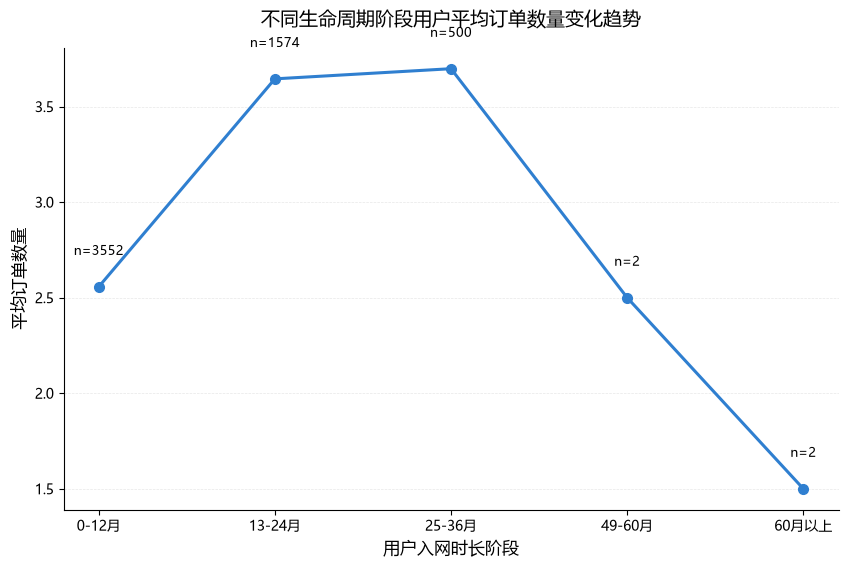

已输出： output\day06_visualization\03_ordered_line.png


In [44]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
line = ax_line.plot(
    ordered_summary["TenureGroup"],
    ordered_summary["平均订单数量"],
    marker="o",
    linewidth=2.2,
    color="#2F7FD0",
    markersize=7
)
for x, y, user_num in zip(ordered_summary["TenureGroup"], ordered_summary["平均订单数量"], ordered_summary["用户数"]):
    ax_line.text(
        x,
        y + 0.15,
        f"n={user_num}",
        ha="center",
        va="bottom",
        fontsize=9
    )
# 图表标题、坐标轴设置
ax_line.set_title("不同生命周期阶段用户平均订单数量变化趋势", fontsize=14, pad=16)
ax_line.set_xlabel("用户入网时长阶段", fontsize=12)
ax_line.set_ylabel("平均订单数量", fontsize=12)

# 网格与边框美化
ax_line.grid(axis="y", alpha=0.3, linestyle="--")
ax_line.spines["top"].set_visible(False)
ax_line.spines["right"].set_visible(False)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：用户平均订单数量随入网生命周期呈现先上升、到达峰值后持续下降的倒 U 型变化；中期生命周期用户下单活跃度最高，超长周期用户订单量大幅回落，且长期分组样本量极少，参考性有限。
- 证据：0-12 月（n=3552）：平均订单数量约 2.55，是全量样本基数最大的群体；
13-24 月（n=1574）、25-36 月（n=500）：平均订单量达到峰值区间（约 3.6~3.7），为用户下单活跃度最高点；
49-60 月（n=2）：均值回落至 2.5，样本仅 2 人；
60 月以上（n=2）：平均订单数量跌至 1.5，样本量极低，代表性弱；
前中期（0-36 个月）用户样本充足，变化趋势可信度高；36 个月以上分组样本稀缺，均值波动不具备普遍参考价值。。
- 边界：无法证明入网时长直接导致订单数量升降，不存在因果关系，仅体现分组分布特征；
未区分流失、未流失用户，无法单独对比两类人群的生命周期下单规律；
49-60 月、60 月以上分组样本仅 2 个，均值不具备统计学代表性，不能以此推断长期用户行为；
仅使用订单数量单一指标，未结合现金返还、投诉、满意度等其他维度综合评估用户价值。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [45]:
# TODO：选择构成字段并准备汇总表
composition_field = "PreferedOrderCat"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)

total_user = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total_user

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,PreferedOrderCat,用户数,占比
0,Fashion,826,0.15
1,Grocery,410,0.07
2,Laptop & Accessory,2050,0.36
3,Mobile Phone,2080,0.37
4,Others,264,0.05


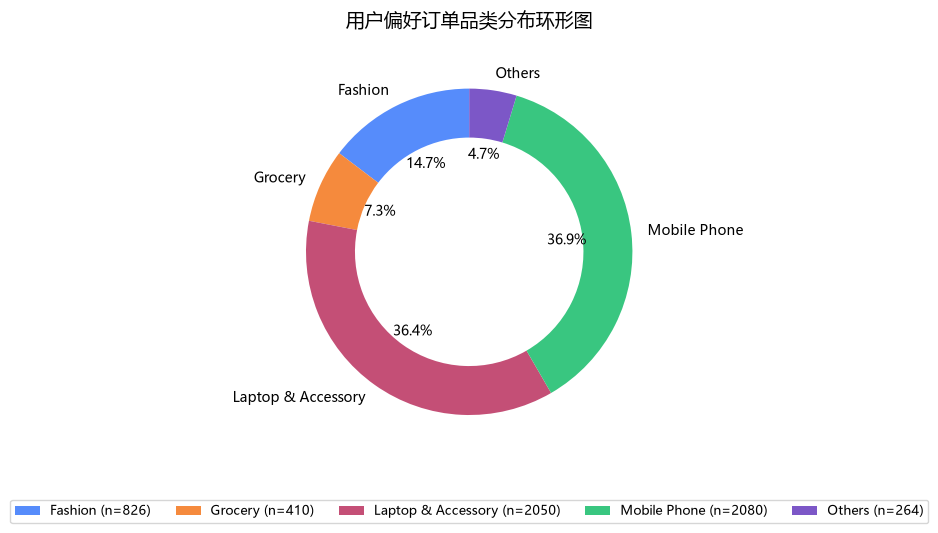

已输出： output\day06_visualization\04_composition_chart.png


In [46]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
category_num = len(composition_summary)

if category_num <= 5:
    # 绘制环形图
    wedges, texts, autotexts = ax_composition.pie(
        composition_summary["用户数"],
        labels=composition_summary[composition_field],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"width": 0.3},  # 空心环形宽度
        textprops={"fontsize": 10}
    )
    # 图例附带每组样本量
    legend_info = [f"{cat} (n={num})" for cat, num in zip(composition_summary[composition_field], composition_summary["用户数"])]
    # 图例放底部，横向5列，不遮挡环形
    ax_composition.legend(wedges, legend_info, loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=5, fontsize=9)
    # 底部预留空白
    fig_composition.subplots_adjust(bottom=0.2)
    ax_composition.set_title("用户偏好订单品类分布环形图", fontsize=14, pad=15)
else:
    # 分类超过5个，绘制占比柱状图
    bars = ax_composition.bar(
        composition_summary[composition_field],
        composition_summary["占比"],
        color="#4472C4"
    )
    # 柱顶标注百分比+样本量
    for bar, ratio, count in zip(bars, composition_summary["占比"], composition_summary["用户数"]):
        h = bar.get_height()
        ax_composition.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.008,
            f"{ratio:.1%}\nn={count}",
            ha="center", va="bottom", fontsize=9
        )
    # 坐标轴与美化
    ax_composition.set_title("用户偏好订单品类占比柱状图", fontsize=14, pad=15)
    ax_composition.set_xlabel("偏好订单品类", fontsize=12)
    ax_composition.set_ylabel("用户占比", fontsize=12)
    from matplotlib.ticker import PercentFormatter
    ax_composition.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    plt.setp(ax_composition.get_xticklabels(), rotation=30, ha="right")
    ax_composition.grid(axis="y", alpha=0.3, linestyle="--")
    ax_composition.spines["top"].set_visible(False)
    ax_composition.spines["right"].set_visible(False)


composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：平台用户偏好订单品类呈现两极分化，手机、电脑配件两大电子品类合计占据超 7 成用户，是平台核心客群；日用杂货、时尚、其他小众品类用户占比偏低，小众品类用户规模极小。
- 证据：Mobile Phone（n=2080）占比 36.9%、Laptop & Accessory（n=2050）占比 36.4%，两类用户合计占比 73.3%，样本量均突破 2000，是平台绝对主流群体；
Fashion（n=826）占比 14.7%，为第三大用户群体；
Grocery（n=410）占比 7.3%，日用杂货用户规模较小；
Others（n=264）占比仅 4.7%，样本量最少，属于小众需求群体；
全品类占比相加约 100%，数据完整无缺失。
- 边界：图表仅统计用户人数占比，无法反映各品类用户订单总量、消费金额、现金返还、流失率等用户价值指标。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [47]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


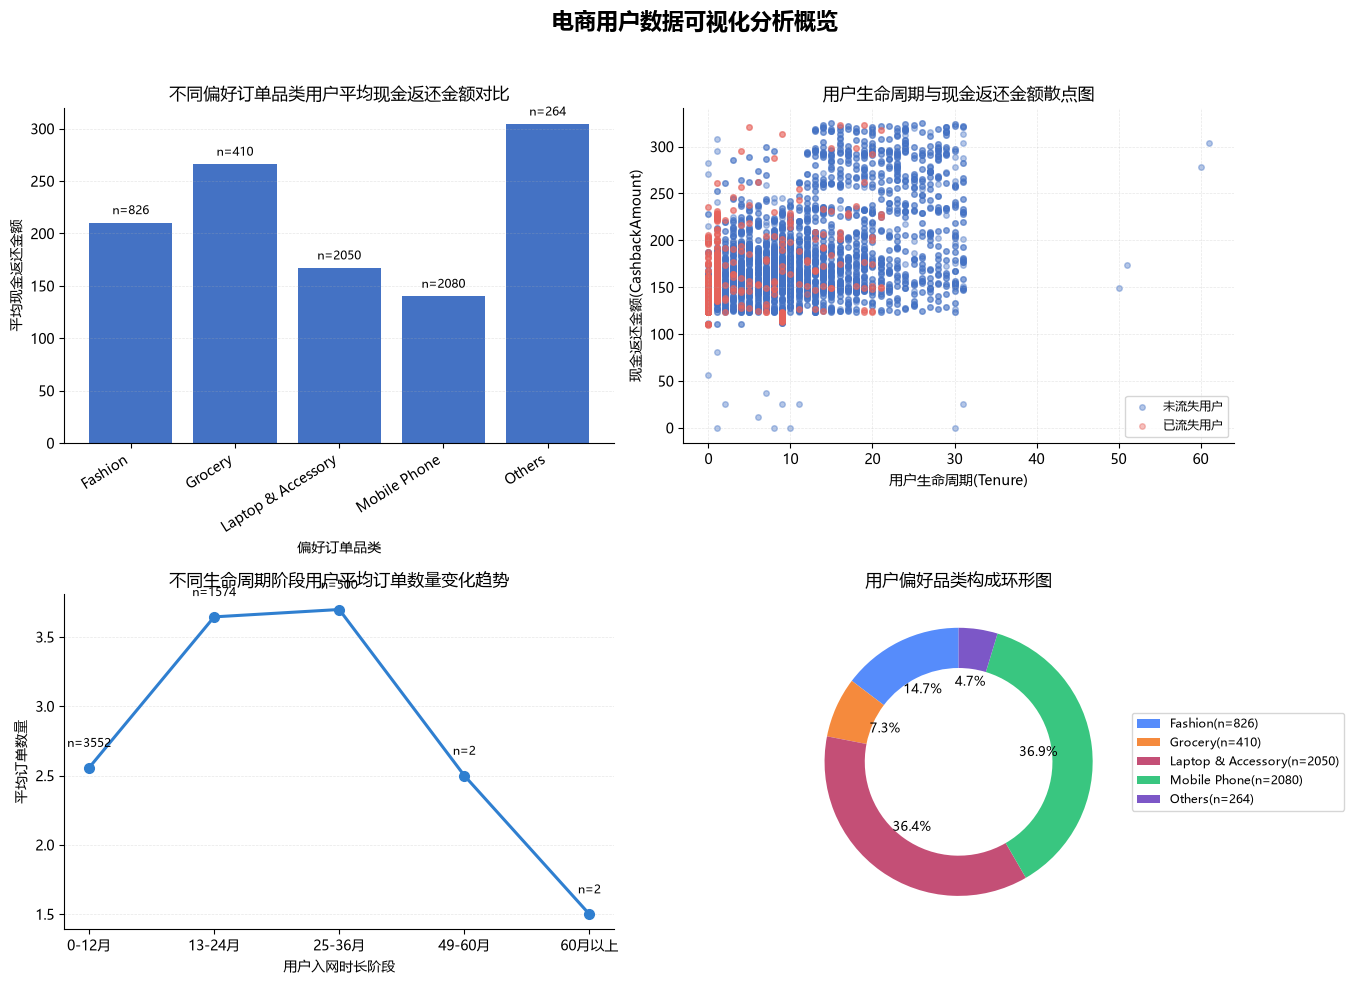

已输出： output\day06_visualization\day06_visualization_summary.png


In [48]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
ax00, ax01 = axes[0, 0], axes[0, 1]
ax10, ax11 = axes[1, 0], axes[1, 1]

color_main = "#4472C4"
color_churn0 = "#4472C4"
color_churn1 = "#E7635C"
color_line = "#2F7FD0"

#子图1：axes[0,0] 品类柱状图（category_bar）
# ======================
bars = ax00.bar(
    category_summary["PreferedOrderCat"],
    category_summary["平均现金返还金额"],
    color=color_main
)
# 标注样本量 n=xxx
for bar, count in zip(bars, category_summary["用户数"]):
    h = bar.get_height()
    ax00.text(
        bar.get_x() + bar.get_width()/2,
        h + 8,
        f"n={count}",
        ha="center", fontsize=8.5
    )
ax00.set_title("不同偏好订单品类用户平均现金返还金额对比", fontsize=12)
ax00.set_xlabel("偏好订单品类", fontsize=10)
ax00.set_ylabel("平均现金返还金额", fontsize=10)
plt.setp(ax00.get_xticklabels(), rotation=32, ha="right")
ax00.grid(axis="y", alpha=0.3, linestyle="--")
ax00.spines["top"].set_visible(False)
ax00.spines["right"].set_visible(False)

# ======================
# 子图2：axes[0,1] 散点图 Tenure & OrderCount（behavior_scatter）
# ======================
df_churn0 = df[df["Churn"] == 0]
df_churn1 = df[df["Churn"] == 1]
ax01.scatter(df_churn0["Tenure"], df_churn0["CashbackAmount"],
             c=color_churn0, alpha=0.4, s=16, label="未流失用户")
ax01.scatter(df_churn1["Tenure"], df_churn1["CashbackAmount"],
             c=color_churn1, alpha=0.4, s=16, label="已流失用户")

ax01.set_title("用户生命周期与现金返还金额散点图", fontsize=12)
ax01.set_xlabel("用户生命周期(Tenure)", fontsize=10)
ax01.set_ylabel("现金返还金额(CashbackAmount)", fontsize=10)
ax01.legend(fontsize=8.5)
ax01.grid(alpha=0.3, linestyle="--")
ax01.spines["top"].set_visible(False)
ax01.spines["right"].set_visible(False)

# ======================
# 子图3：axes[1,0] 有序折线图 TenureGroup平均订单（ordered_line）
# ======================
ax10.plot(
    ordered_summary["TenureGroup"],
    ordered_summary["平均订单数量"],
    marker="o",
    linewidth=2.2,
    color=color_line,
    markersize=7
)
# 标注样本量
for x, y, user_num in zip(ordered_summary["TenureGroup"], ordered_summary["平均订单数量"], ordered_summary["用户数"]):
    ax10.text(
        x, y + 0.15,
        f"n={user_num}",
        ha="center", fontsize=8.5
    )
ax10.set_title("不同生命周期阶段用户平均订单数量变化趋势", fontsize=12)
ax10.set_xlabel("用户入网时长阶段", fontsize=10)
ax10.set_ylabel("平均订单数量", fontsize=10)
ax10.grid(axis="y", alpha=0.3, linestyle="--")
ax10.spines["top"].set_visible(False)
ax10.spines["right"].set_visible(False)

# ======================
# 子图4：axes[1,1] 环形构成图 composition_chart
# ======================
cat_num = len(composition_summary)
if cat_num <=5:
    wedges, texts, autotexts = ax11.pie(
        composition_summary["用户数"],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"width":0.3},
        textprops={"fontsize":9}
    )
    leg_labels = [f"{cat}(n={cnt})" for cat,cnt in zip(composition_summary[composition_field], composition_summary["用户数"])]
    ax11.legend(wedges, leg_labels, loc="center left", bbox_to_anchor=(1,0.5), fontsize=8.5)
ax11.set_title("用户偏好品类构成环形图", fontsize=12)

# 全局总标题、布局统一
fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：小众品类 Others 用户平均现金返还金额最高，主流电子品类返现水平偏低证据。
2. 综合发现2：用户平均订单数量随生命周期呈倒 U 型变化，中周期用户下单活跃度最高，超长周期用户样本稀缺不具备参考性。
3. 综合发现3：用户生命周期与现金返还无明显线性关联，同周期内流失、未流失用户返现分布高度重叠。
4. 数据或方法局限：仅使用现金返还金额 CashbackAmount，不代表平台营收、GMV、利润，高额返现不对应高消费贡献，无法衡量品类真实商业价值；
样本缺陷：超长生命周期 49-60 月、60 月以上分组仅 2 个用户，样本过少，生命周期趋势尾部数据不具备统计学代表性；
维度单一：仅基于用户偏好单一标签做静态截面分析，无法观测同一用户跨品类下单行为，也不能体现用户偏好、返现、下单量随时间动态变化；
未拆分对比：所有图表未对同一生命周期、同一品类下流失 / 未流失用户做单独指标拆分，无法精准定位流失人群行为差异；
仅描述相关性：所有可视化仅展示变量分布与关联趋势，无统计检验，无法证明变量间存在因果关系。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [49]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同偏好订单品类的平均现金返还金额是否存在差异？", "chart_type": "bar", "key_finding": "小众品类 Others 用户平均现金返还金额最高，主流电子品类返现水平偏低证据。", "limitation": "仅使用现金返还金额 CashbackAmount，不代表平台营收、GMV、利润，高额返现不对应高消费贡献，无法衡量品类真实商业价值"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "用户生命周期与现金返还金额呈现什么关系？", "chart_type": "scatter", "key_finding": "用户平均订单数量随生命周期呈倒 U 型变化，中周期用户下单活跃度最高，超长周期用户样本稀缺不具备参考性", "limitation": "超长生命周期 49-60 月、60 月以上分组仅 2 个用户，样本过少，生命周期趋势尾部数据不具备统计学代表性"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "用户平均订单数量如何随用户生命周期阶段性变化？", "chart_type": "line", "key_finding": "用户生命周期与现金返还无明显线性关联，同周期内流失、未流失用户返现分布高度重叠", "limitation": "仅基于用户偏好单一标签做静态截面分析，无法观测同一用户跨品类下单行为，也不能体现用户偏好、返现、下单量随时间动态变化"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "全部用户由哪些偏好订单品类类别构成？", "chart_type": "pie_or_bar", "key_finding": "平台用户偏好订单品类呈现两极分化，手机、电脑配件两大电子品类合计占据超 7 成用户，是平台核心客群；日用杂货、时尚、其他小众品类用户占比偏低，小众品类用户规模极小。", "limitation": "无法反映各品类用户订单总量、消费金额、现金返还、流失率等用户价值指标。"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "平台用户集中于手机、电脑配件，该群体基数大但平均返现偏低；用户 13-36 个月下单最活跃，超长周期样本不足。返现金额与生命周期、流失状态无明显关联。", "limitation": "仅基于静态截面用户人数与现金返还指标，现金返还仅为平台补贴，不等同于消费营收；缺少时序动态数据、细分流失人群对比与统计检验，仅能描述分布趋势，无法证明变量间因果关系"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同偏好订单品类的平均现金返还金额是否存在差异？,bar,小众品类 Others 用户平均现金返还金额最高，主流电子品类返现水平偏低证据。,仅使用现金返还金额 CashbackAmount，不代表平台营收、GMV、利润，高额返现不对...
1,02,02_behavior_scatter.png,用户生命周期与现金返还金额呈现什么关系？,scatter,用户平均订单数量随生命周期呈倒 U 型变化，中周期用户下单活跃度最高，超长周期用户样本稀缺不...,超长生命周期 49-60 月、60 月以上分组仅 2 个用户，样本过少，生命周期趋势尾部数据...
2,03,03_ordered_line.png,用户平均订单数量如何随用户生命周期阶段性变化？,line,用户生命周期与现金返还无明显线性关联，同周期内流失、未流失用户返现分布高度重叠,仅基于用户偏好单一标签做静态截面分析，无法观测同一用户跨品类下单行为，也不能体现用户偏好、返...
3,04,04_composition_chart.png,全部用户由哪些偏好订单品类类别构成？,pie_or_bar,平台用户偏好订单品类呈现两极分化，手机、电脑配件两大电子品类合计占据超 7 成用户，是平台核...,无法反映各品类用户订单总量、消费金额、现金返还、流失率等用户价值指标。
4,05,day06_visualization_summary.png,整体概览,dashboard,平台用户集中于手机、电脑配件，该群体基数大但平均返现偏低；用户 13-36 个月下单最活跃，...,仅基于静态截面用户人数与现金返还指标，现金返还仅为平台补贴，不等同于消费营收；缺少时序动态数...


In [50]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
